# Run this first !

In [15]:
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data


In [ ]:
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-23")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-23")
met = loading.load(DATA, "all_metrics.csv", "2026-09-23")

print(utt.shape, sent.shape, met.shape)
sent.head()

['2026-09-13']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen."
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...
2,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9791,3,This call is being recorded.
3,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9792,4,Your line will be muted for the duration of th...
4,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9793,5,We will now go live to the presentation.


In [17]:
#utt.head(5)

In [18]:
#met.head(10)

In [19]:
data=sent.copy()

# Data distributions

## Missing values
All OK apart from Speaker Institution (probably not needed anyway)

In [20]:
# Missing data
data.isnull().sum()

bank                      0
quarter                   0
call_type                 0
call_date                 0
position_in_call          0
section                   0
speaker_role              0
speaker_name              0
speaker_institution    7133
sentence_id               0
sentence_number           0
sentence                  0
dtype: int64

In [21]:
# Count values for 'speaker institution' including NaN
data['speaker_institution'].value_counts(dropna=False)

speaker_institution
NaN                          7133
Morgan Stanley                265
Deutsche Bank                 173
Bank of America               165
Wells Fargo Securities        150
Citi                          128
RBC Capital Markets           125
Autonomous Research           125
BNP Paribas Exane             112
UBS                           107
JPMorgan                      102
Evercore ISI                   97
Mediobanca                     96
Seaport Global Securities      95
Goldman Sachs                  90
Jefferies                      88
Wolfe Research                 79
RBC                            74
Société Générale               60
HSBC                           45
Barclays                       44
Portales Partners              43
KBW                            40
HSBC Securities                36
Kepler Cheuvreux               21
Truist Securities              13
Piper Sandler                  13
Name: count, dtype: int64

## Sentence numbers
Almost the same number of sentences for each bank - although JPM has 4 x Q&A sentences compared to prepared text, whereas UBS has almost the same

In [22]:
# Count total sentances from each of the banks
data['bank'].value_counts(dropna=False)

bank
JPM    4805
UBS    4714
Name: count, dtype: int64

In [23]:
# Count different sections in the data - which come from reports and which from Q&A for each bank
data.groupby('bank')['section'].value_counts(dropna=False)


bank  section 
JPM   qa          3863
      prepared     942
UBS   qa          2653
      prepared    2061
Name: count, dtype: int64

## Call Date vs Quarter

There were two calls in Q2 2023 for JPMorgan due to the takeover (14t/04/2023 and 01/05/2023). This means the number of sentences in Q2 includes both of these calls and is therefore significantly larger


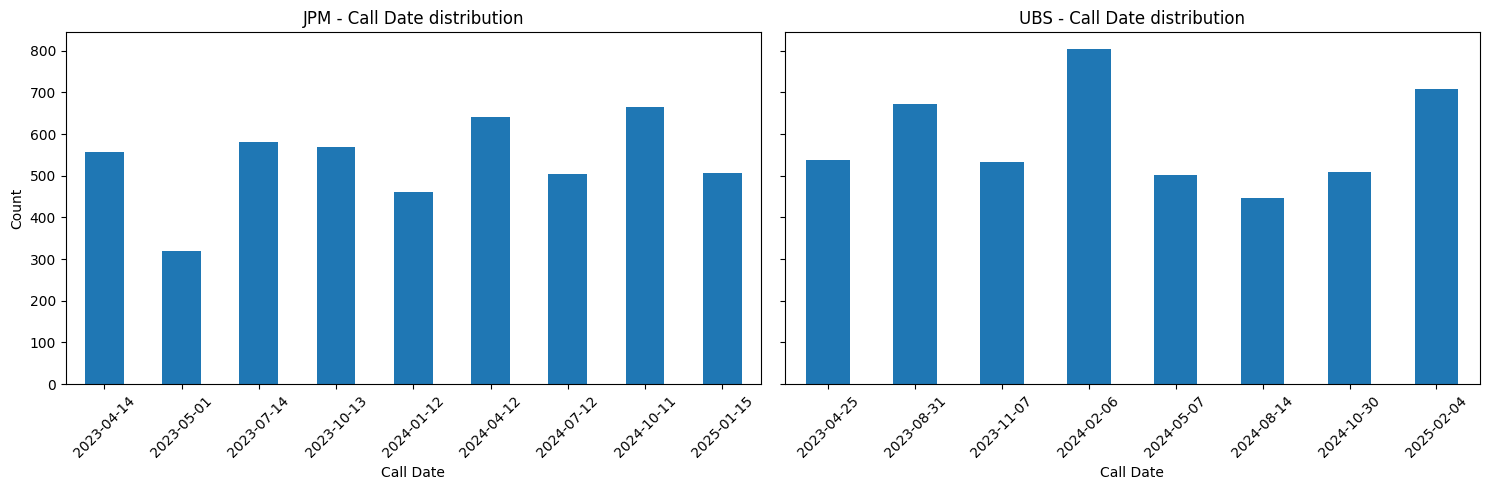

In [24]:
# Plot call_date distributions for each bank in side-by-side subplots
banks = data['bank'].dropna().unique()
fig, axes = plt.subplots(1, len(banks), figsize=(15, 5), sharey=True)

for ax, bank in zip(axes, banks):
    subset = data[data['bank'] == bank]
    counts = subset['call_date'].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{bank} - Call Date distribution')
    ax.set_xlabel('Call Date')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

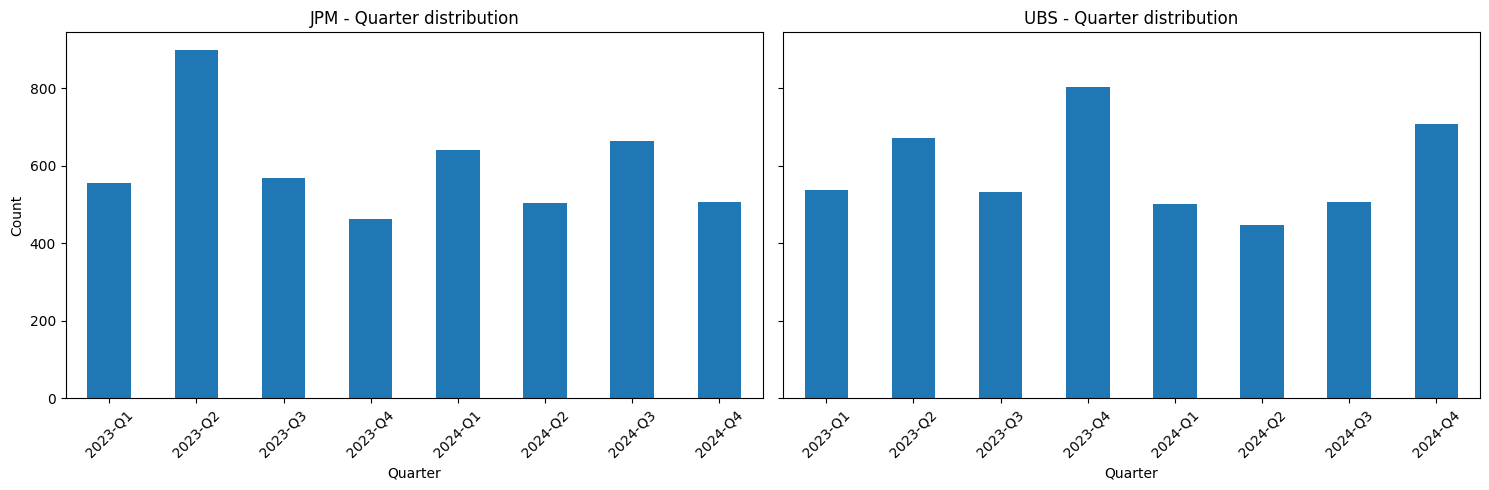

In [25]:
# Plot quarter distributions for each bank in side-by-side subplots
banks = data['bank'].dropna().unique()
fig, axes = plt.subplots(1, len(banks), figsize=(15, 5), sharey=True)

for ax, bank in zip(axes, banks):
    subset = data[data['bank'] == bank]
    counts = subset['quarter'].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{bank} - Quarter distribution')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

## Speaker Names
Need to remove these from the sentences

In [1]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

NameError: name 'data' is not defined

## Initial Word Clouds per bank
Not particularly useful as data has not been processed yet to remove greetings, names, stop words etc.

In [27]:
# Install WordCloud
%pip install wordcloud
from wordcloud import WordCloud

Note: you may need to restart the kernel to use updated packages.


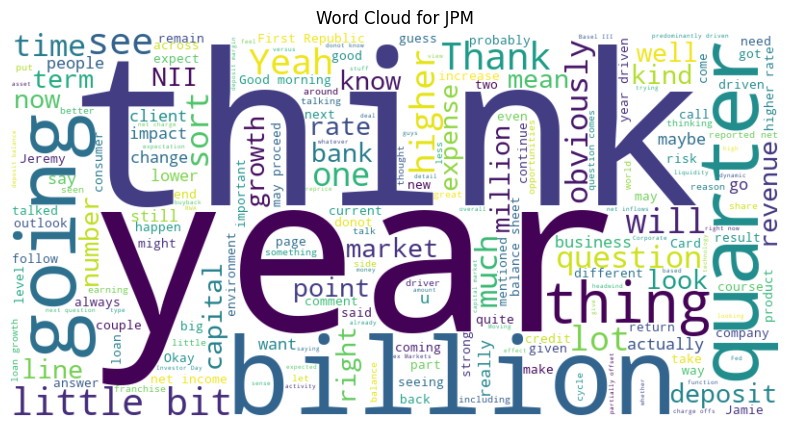

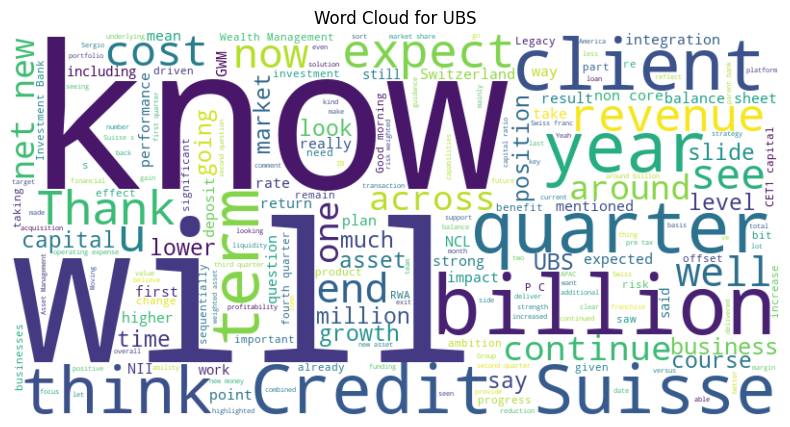

In [28]:
# Create word cloud from the text in the 'sentence' column for each bank name
for bank in data['bank'].unique():
    text = ' '.join(data.loc[data['bank'] == bank, 'sentence'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {bank}')
    plt.show()

## Top 20 words
Useful to see which words need to be removed for the pre-processing (stop words, greetings etc)

In [36]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Preprocessing function

In [ ]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove words that are not informative for topic modeling
    stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats'])

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]
    

    greeting_words = {
    "hello", "hi", "dear", "greetings",
    "thank", "thanks", "good", "morning",
    "afternoon", "evening",
    "ladies", "gentlemen", "sir", "madam",
    "yeah", "welcome",
    "mr", "mrs", "ms"
}

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and word.isalpha() and word not in greeting_words and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [40]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                            sentence  \
0                Good morning, ladies and gentlemen.   
1  Welcome to JPMorgan Chase’s First Quarter 2023...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   
5                                   Please stand by.   
6  At this time, I would like to turn the call ov...   
7                       Mr. Barnum, please go ahead.   
8                Thanks, and good morning, everyone.   
9  The presentation is available on our website, ...   

                                        cleaned_text  
0                                                 []  
1           [jpmorgan, chase, first, earnings, call]  
2                                   [call, recorded]  
3                      [line, muted, duration, call]  
4                           [go, live, presentation]  
5                                    [please, stand] 

Top 20 most common words in conversation text:
[('billion', 1056), ('capital', 667), ('know', 611), ('market', 559), ('client', 550), ('net', 540), ('question', 507), ('revenue', 503), ('credit', 500), ('rate', 488), ('cost', 464), ('business', 458), ('well', 458), ('going', 434), ('deposit', 433), ('term', 427), ('would', 421), ('first', 391), ('asset', 391), ('higher', 379)]


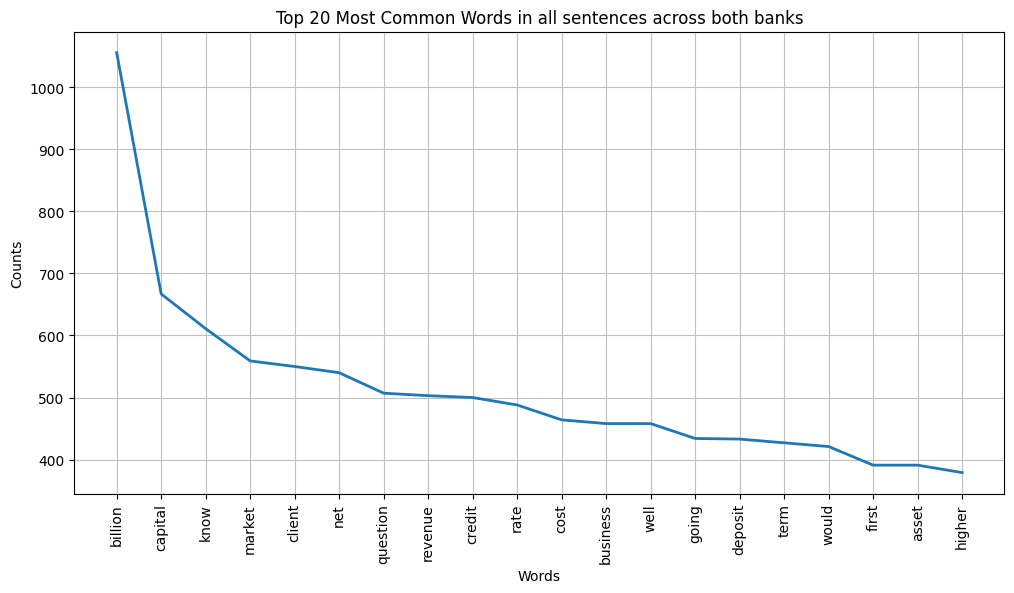

In [32]:
# Flatten the cleaned text into one list for the frequency distribution
data_all_words = [word for tokens in data['cleaned_text'] for word in tokens]

# Calculate frequency distribution
data_freq_dist = nltk.FreqDist(data_all_words)

# Display the top 20 most common words
print("Top 20 most common words in conversation text:")
print(data_freq_dist.most_common(20))

# Plotting the top 20 words
plt.figure(figsize=(12, 6))
data_freq_dist.plot(20, title='Top 20 Most Common Words in all sentences across both banks', cumulative=False)
plt.xlabel('Words')
plt.show()

Still has words like "would" & "going"

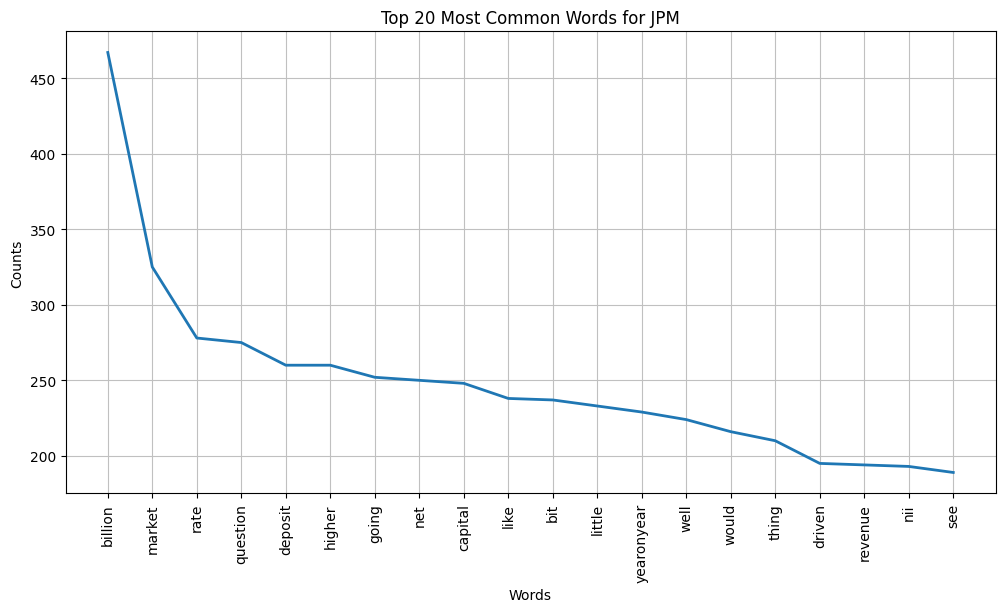

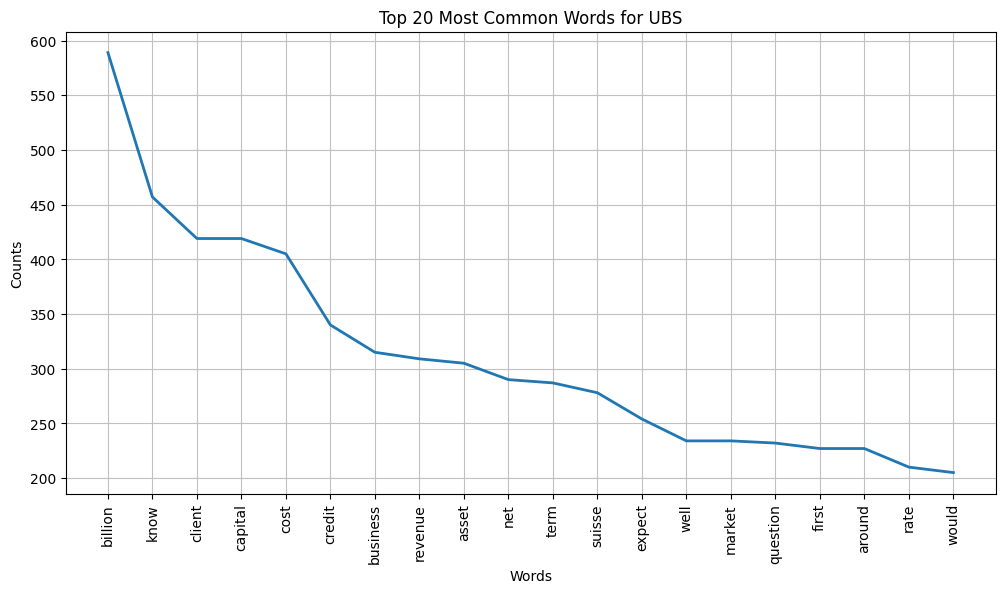

In [33]:
# Calculate frequency distribution for each bank
bank_freq_dists = {}
for bank in data['bank'].unique():
    bank_words = [word for tokens in data.loc[data['bank'] == bank, 'cleaned_text'] for word in tokens]
    bank_freq_dists[bank] = nltk.FreqDist(bank_words)
    plt.figure(figsize=(12, 6))
    bank_freq_dists[bank].plot(20, title=f'Top 20 Most Common Words for {bank}', cumulative=False)
    plt.xlabel('Words')
    plt.show()

UBS has credit and suisse in the top 20 - some of which are the bank "credit suisse" and some will be just the word "credit". Need to work out how to deal with this

Also still some words that may need checking - is "going" followed by "well" or "badly"?